# Step 2: Adding Object Detections to a FiftyOne Dataset
In our first step, we will be covering how you can add object detections to your dataset. First we will go through how to add predictions using the FiftyOne Model Zoo and apply_model. In the second part, we will demonstrate how to add your detection predictions from your own custom model or labels. Feel free to skip ahead if you are interested in only adding object detections with your own model or labels!

In [1]:
import fiftyone as fo
import fiftyone.zoo as foz

fo.list_datasets()

['construction-ppe', 'quickstart-25', 'quickstart-video-2']

In [2]:
dataset = fo.load_dataset("construction-ppe").limit(100)
dataset.summary()


'Dataset:     construction-ppe\nMedia type:  image\nNum samples: 100\nSample fields:\n    id:                      fiftyone.core.fields.ObjectIdField\n    filepath:                fiftyone.core.fields.StringField\n    tags:                    fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)\n    metadata:                fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)\n    created_at:              fiftyone.core.fields.DateTimeField\n    last_modified_at:        fiftyone.core.fields.DateTimeField\n    ground_truth:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)\n    coco_predictions:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)\n    YOLOv8:                  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)\n    torchvision:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)\n    segmentations:        

With FiftyOne, you have tons of pretrained models at your disposal to use via the [FiftyOne Model Zoo](https://docs.voxel51.com/model_zoo/index.html) or using one of our [integrations](https://docs.voxel51.com/integrations/index.html) such as [HuggingFace](https://docs.voxel51.com/integrations/huggingface.html)! To get started using them, first load the model in and pass it into the apply_model function. 

We will use [retinanet-resnet50-fpn-coco-torch](https://docs.voxel51.com/model_zoo/models.html#retinanet-resnet50-fpn-coco-torch) from the model zoo first!

In [5]:
model = foz.load_zoo_model("retinanet-resnet50-fpn-coco-torch")
dataset.apply_model(model, label_field="coco_predictions")

 100% |██████|    1.0Gb/1.0Gb [14.5s elapsed, 0s remaining, 85.9Mb/s]      


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /Users/hassanbadawy/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth
100%|██████████| 130M/130M [00:16<00:00, 8.53MB/s] 


  21% |███------------|  291/1416 [3.9m elapsed, 15.8m remaining, 1.0 samples/s]  

libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x17a9a44a0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rasid360/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/opt/anaconda3/envs/rasid360/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1582, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/anaconda3/envs/rasid360/lib/python3.11/multiprocessing/process.py",

  21% |███\-----------|  291/1416 [3.9m elapsed, 15.9m remaining, 1.0 samples/s]  


KeyboardInterrupt: 

Let's visualize our results!

Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port



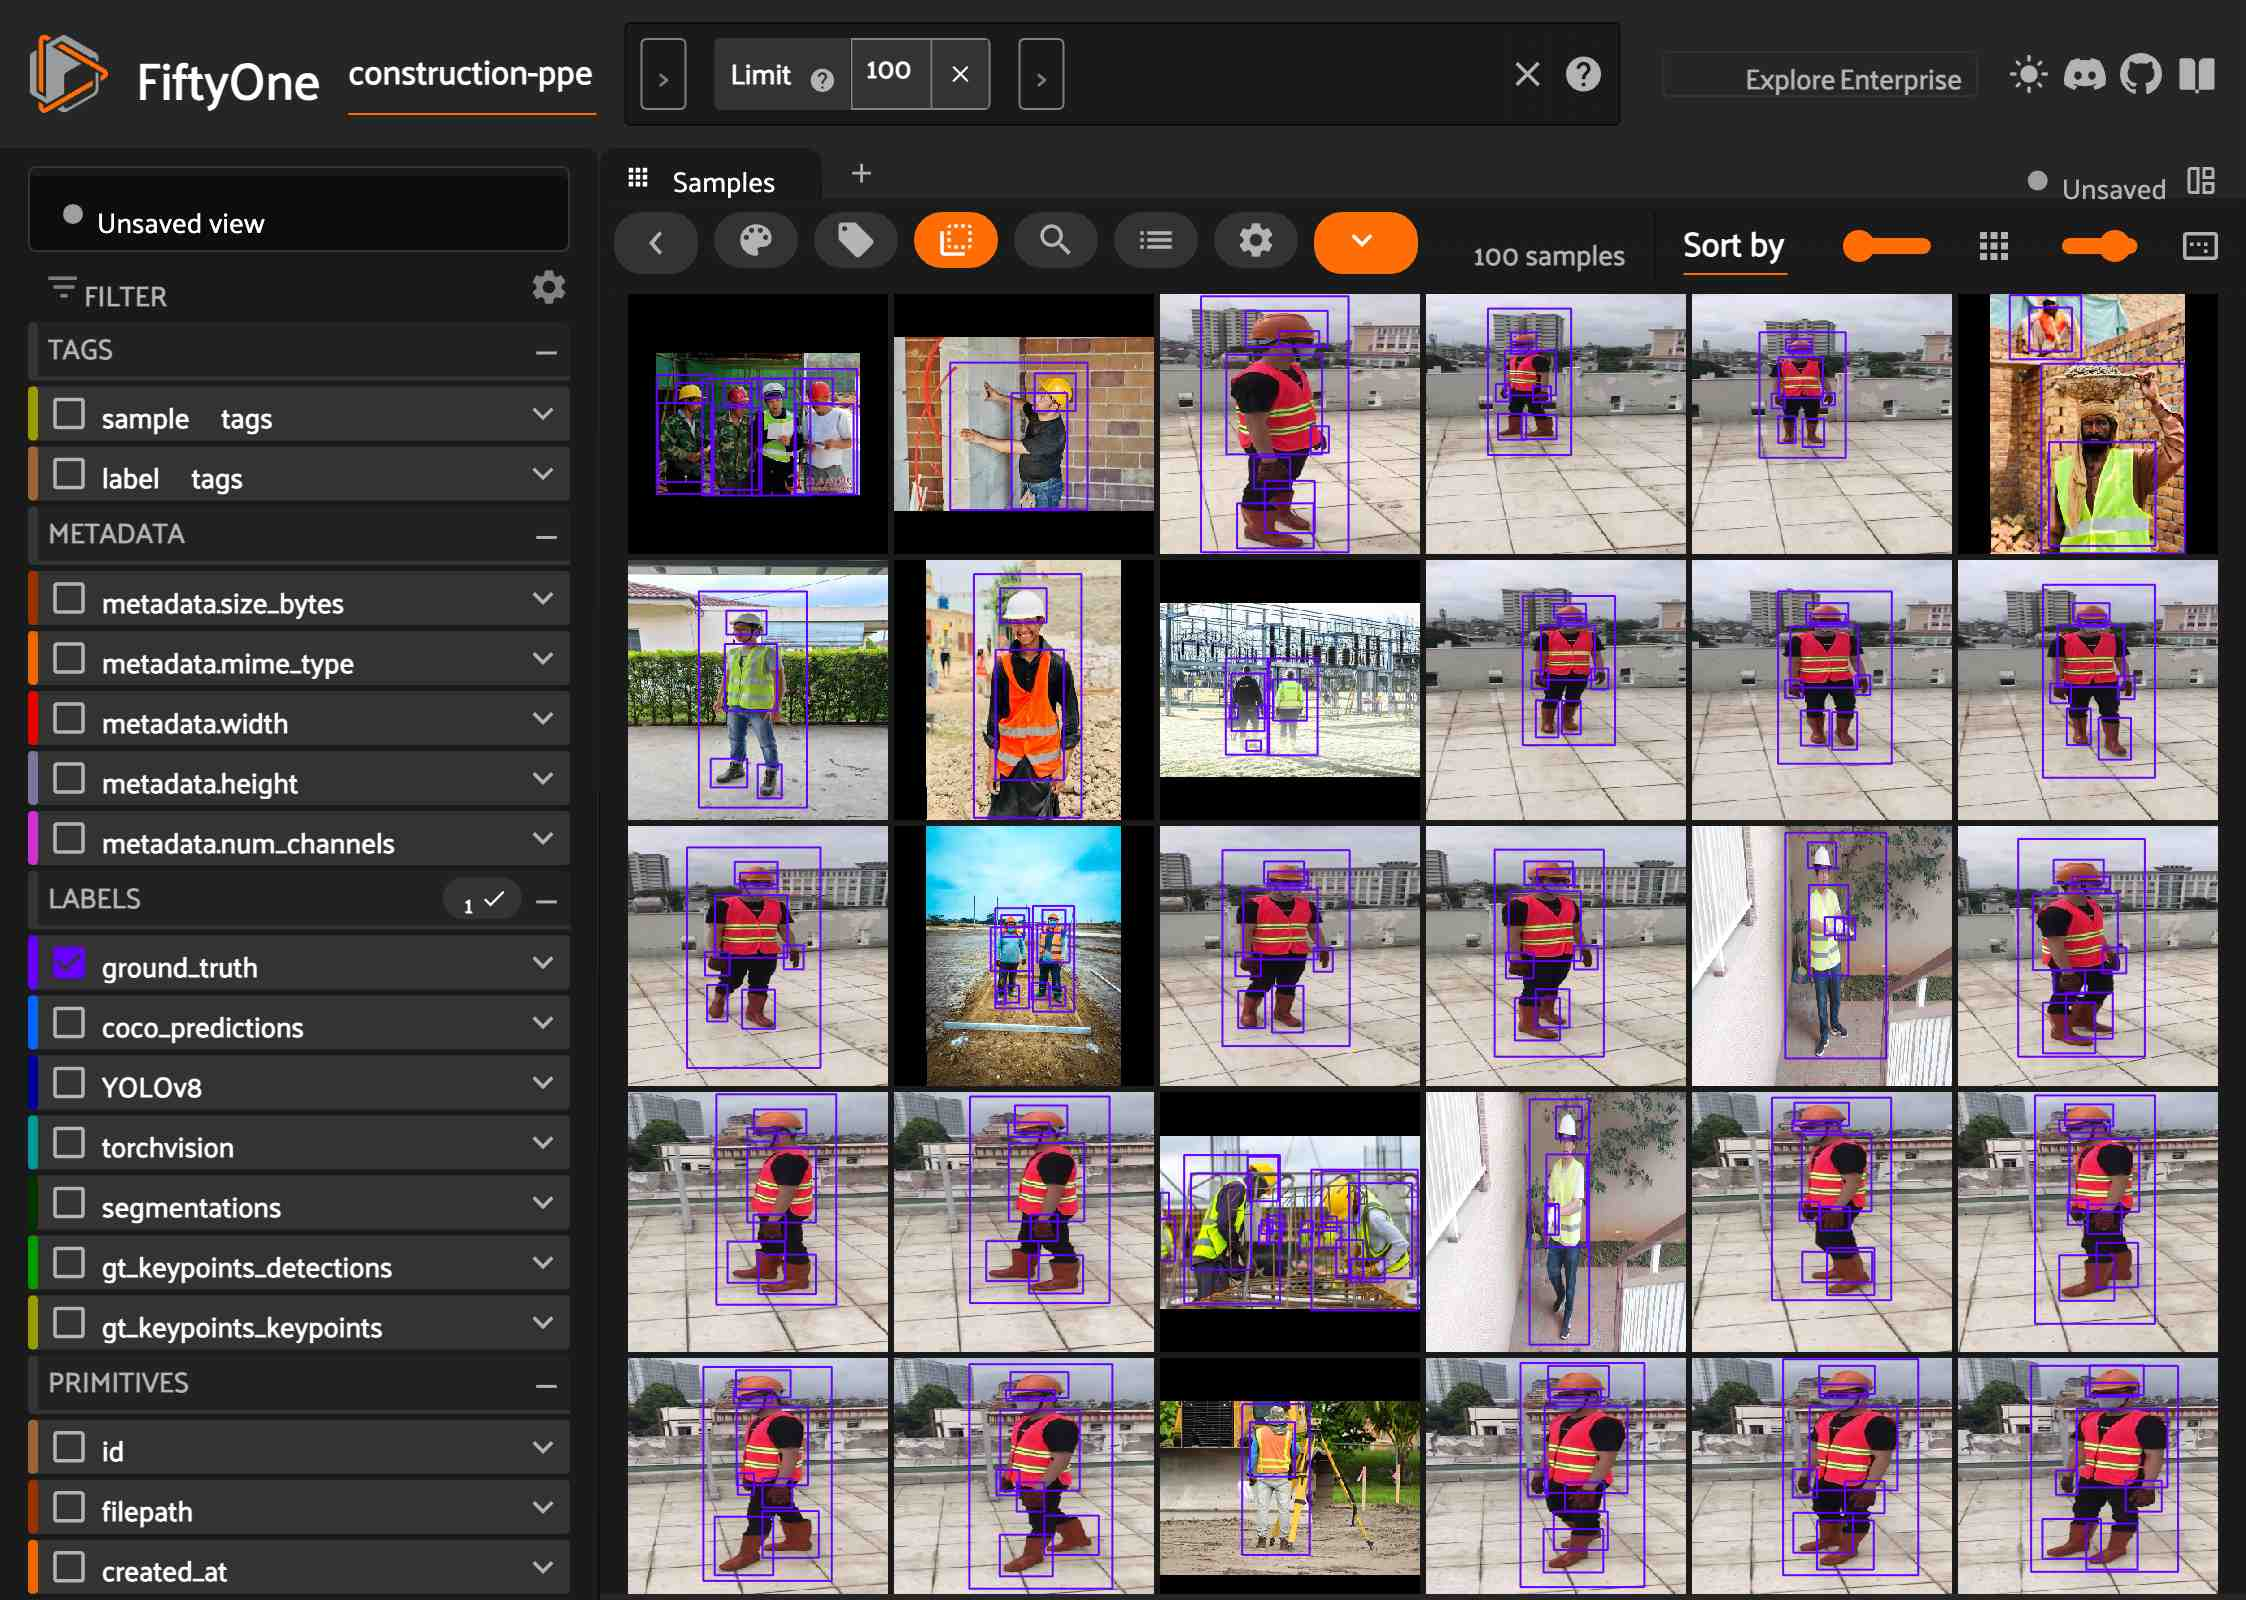


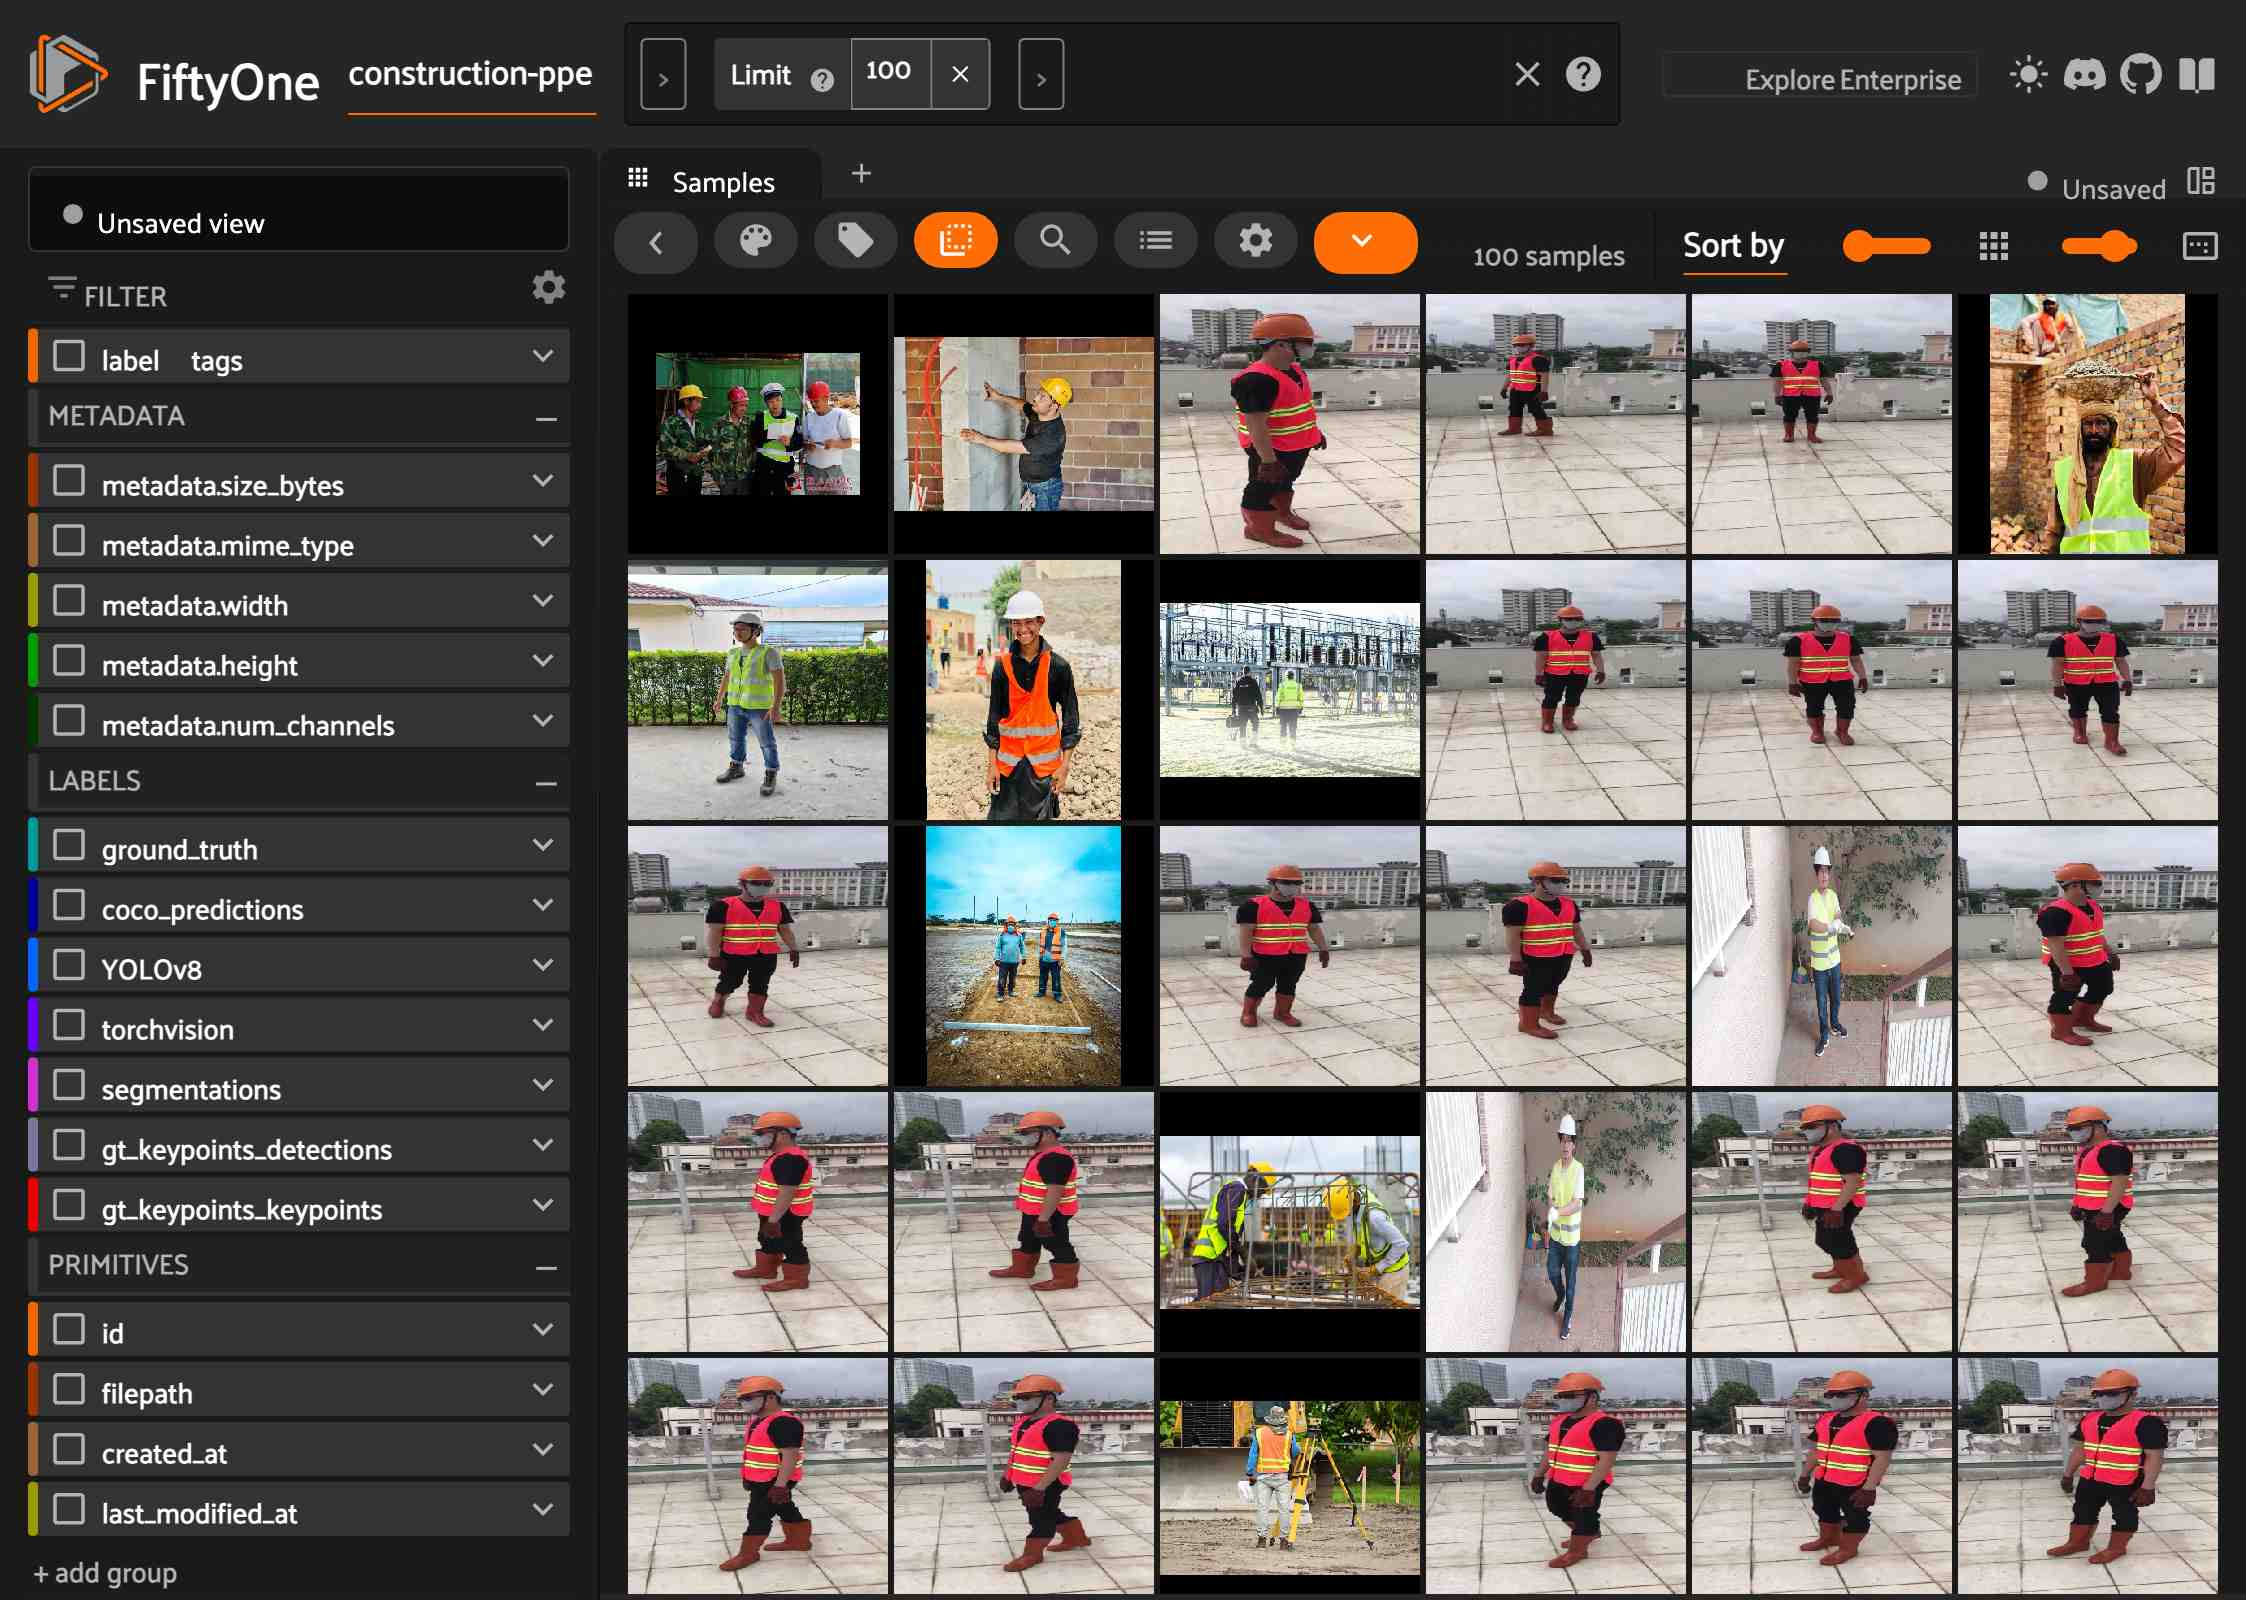

In [3]:
session = fo.launch_app(dataset)
session.show()

## Adding Predictions using Ultralytics
Thanks to [FiftyOne's integration](https://docs.voxel51.com/integrations/ultralytics.html) with [Ultralytics](https://github.com/ultralytics/ultralytics), we can pass any Ultralytics YOLO model into apply_model as well!

In [13]:
%%capture
!pip install ultralytics

In [5]:
from ultralytics import YOLO

# YOLOv8
model = YOLO("yolov8s.pt")

dataset.apply_model(model, label_field="YOLOv8")

 100% |█████████████████| 100/100 [19.6s elapsed, 0s remaining, 7.5 samples/s]      



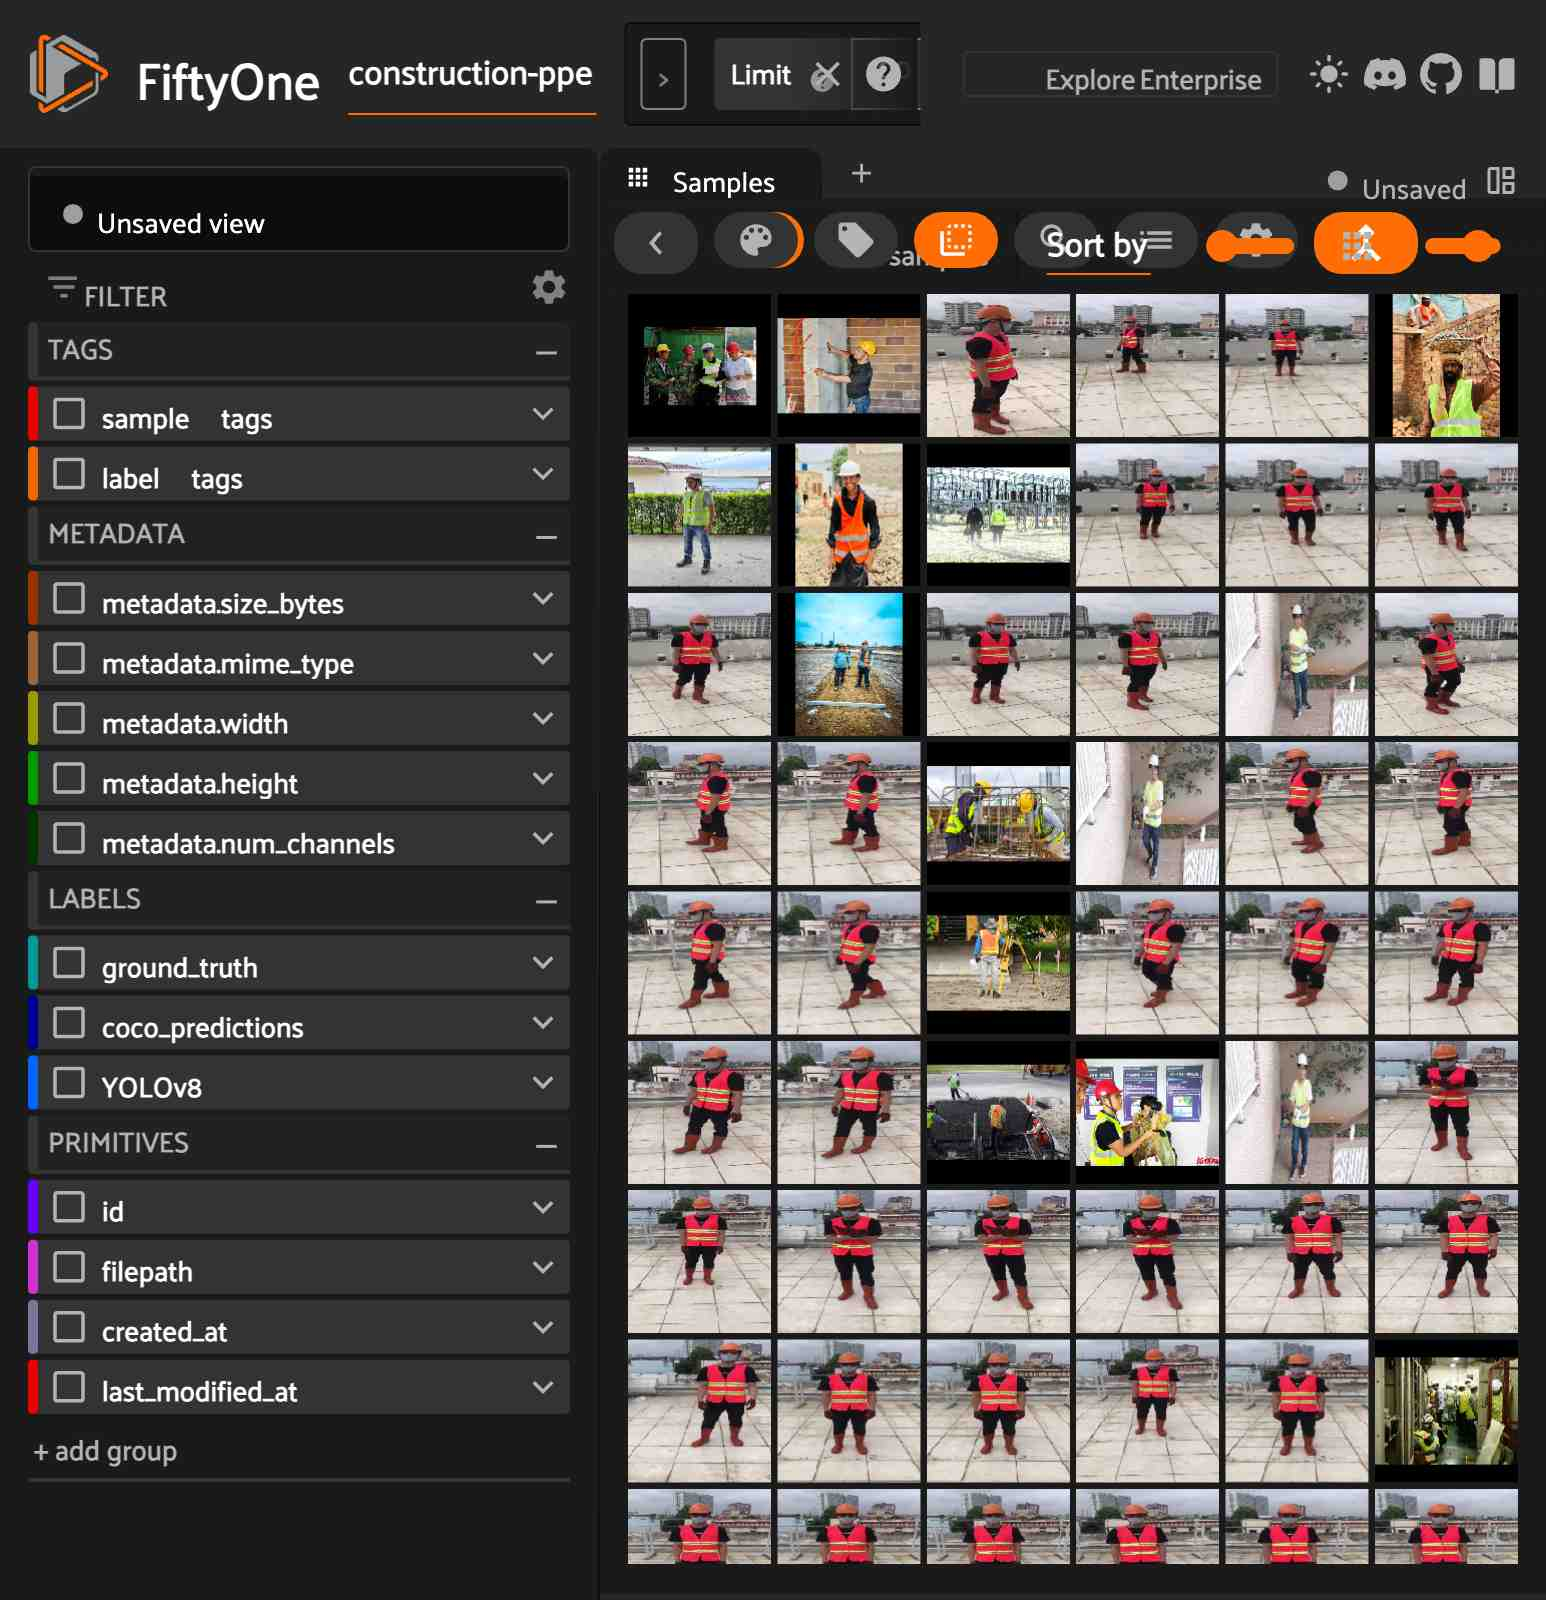

In [6]:
session.show()

## Adding Predictions from Custom Model
When bringing your own model to add predictions to your dataset, you can add [detection labels](https://docs.voxel51.com/user_guide/using_datasets.html#object-detection) directly to each sample! The __most__ important part to remember is that FiftyOne uses `[nx, ny, nw, nh]` bounding box format, or normalized x,y,w,h notation. This means that each value in the bounding box is between (0,1). Below is a sample function that converts an `xyxy` box to `nxywh`.

In [7]:
def convert_xyxy_boxes(sample, boxes):
    new_boxes = []
    
    for box in boxes:
        
        # Normalize X and Y by width and height
        nx = box[0] / sample.metadata.width
        ny = box[1] / sample.metadata.height
        
        # Calculate width and height and normalize as well
        nw = (box[2] - box[0]) / sample.metadata.width
        nh = (box[3] - box[1]) / sample.metadata.height
        new_box = [nx, ny, nw, nh]
        new_boxes.append(new_box)
        
    return new_boxes

For our custom model in this example, we will be using torchvision [FasterRCNN_Resnet50](https://docs.voxel51.com/user_guide/using_datasets.html#object-detection). The pattern for adding custom labels looks like this:

1. Load the sample image
2. Perform any necessary preprocessing
3. Inference on the image
4. Grab the prediction and confidence of the model_output
5. Adjust the bounding box if needed
6. Add the values as a label to your sample

Let's walkthrough them below!

In [8]:
from torchvision.io.image import read_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)

# Compute Metadata to collect each samples width and height
dataset.compute_metadata() 

for sample in dataset:
    # Step 1: Load the image
    image = read_image(sample.filepath)

    # Step 2: Preform preprocessing
    preprocess = weights.transforms()

    batch = [preprocess(image)]

    # Step 3: Inference on the image
    model.eval()
    prediction = model(batch)[0]
    
    # Step 4: Grab the prediction and confidence
    labels = [weights.meta["categories"][i] for i in prediction["labels"]]
    confs = prediction["scores"].tolist()

    # Step 5: Convert the boxes to FiftyOne format
    fo_boxes = convert_xyxy_boxes(sample, prediction["boxes"].tolist())
    detections = []
    
    # Step 6: Add to your sample
    for cls, box, conf in zip(labels, fo_boxes, confs):
        
        det = fo.Detection(label=cls, bounding_box=box, confidence=conf)
        detections.append(det)
        
    sample["torchvision"] = fo.Detections(detections=detections)
    sample.save()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /Users/hassanbadawy/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [00:19<00:00, 8.92MB/s] 


Computing metadata...
 100% |█████████████████| 100/100 [36.5ms elapsed, 0s remaining, 2.7K samples/s] 


Finally, we can see all of our results in the FiftyOne App!

In [ ]:
session.show()

![torchvision-predictions](https://cdn.voxel51.com/torchvision-predictions.webp)

## Summary

You've added object detections using Model Zoo models, Ultralytics YOLO, and custom models. Remember: FiftyOne uses normalized `[nx, ny, nw, nh]` bounding box format.

Next up: **Step 3 covers finding detection mistakes**